In [42]:
import xspec 
from datetime import datetime
import os
import sys
import numpy as np
from astropy.io import fits
import matplotlib
import matplotlib.pyplot as plt
import os
from solexs_tools.solexs_genspec import solexs_genspec
from tqdm.notebook import tqdm as tqdm
import scienceplots

plt.style.use(['science','no-latex'])
plt.plot(); plt.close();


# Load SoLEXS data files 

In [43]:
gti_filename = '/home/idies/workspace/sciserver_cookbooks/SoLEXS/Data/AL1_SLX_L1_20241001_v1.0/SDD2/AL1_SOLEXS_20241001_SDD2_L1.gti.gz'
lc_filename = '/home/idies/workspace/sciserver_cookbooks/SoLEXS/Data/AL1_SLX_L1_20241001_v1.0/SDD2/AL1_SOLEXS_20241001_SDD2_L1.lc.gz'
pi_filename = '/home/idies/workspace/sciserver_cookbooks/SoLEXS/Data/AL1_SLX_L1_20241001_v1.0/SDD2/AL1_SOLEXS_20241001_SDD2_L1.pi.gz'


# Loading light curve (LC) file
lc_hdul = fits.open(lc_filename)
plot_times_UNIX = lc_hdul[1].data['TIME'] # here, time is in UNIX seconds
plot_lcurve = lc_hdul[1].data['COUNTS']

# Loading good time intervals (GTI) file
if(gti_filename is not None):
    gti_hdul = fits.open(gti_filename)
    gti_start_arr_UNIX = gti_hdul[1].data['START'] # here, time is in UNIX seconds
    gti_stop_arr_UNIX = gti_hdul[1].data['STOP'] # here, time is in UNIX seconds


# Plot Light curve with good time interval 

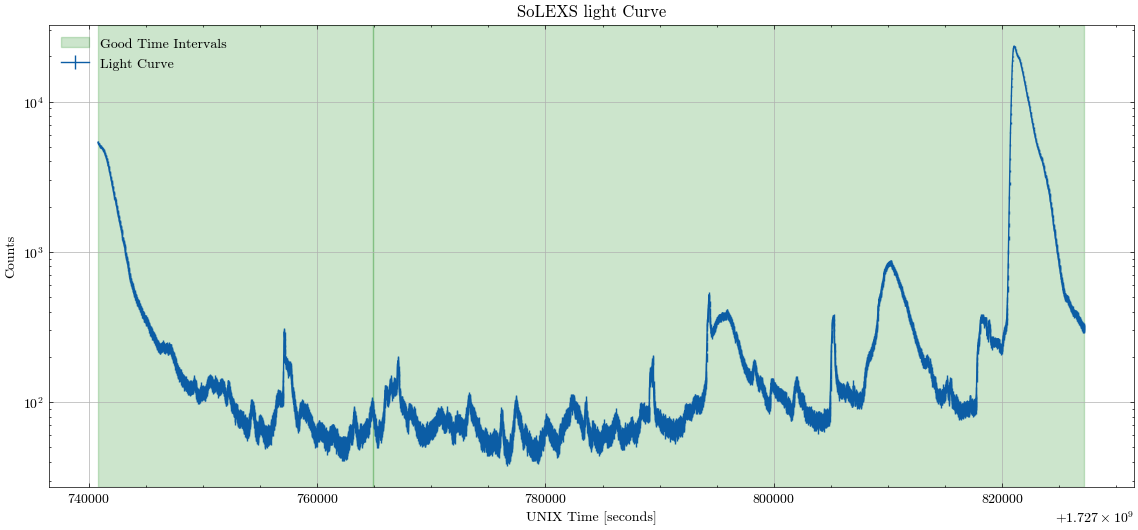

In [67]:
fig, ax = plt.subplots(figsize=(14, 6))

ax.errorbar(plot_times_UNIX,plot_lcurve,yerr=np.sqrt(plot_lcurve),label='Light Curve')

if(gti_filename is not None):
    for n,i,j in zip(np.arange(len(gti_start_arr_UNIX)), gti_start_arr_UNIX, gti_stop_arr_UNIX):
        ax.axvspan(i,j, color='green', alpha=0.2, label='_'*n + 'Good Time Intervals')

ax.legend(loc=0)
ax.grid()
ax.set_yscale('log')

ax.set_xlabel('UNIX Time [seconds]')
ax.set_ylabel('Counts')
ax.set_title('SoLEXS light Curve')
plt.savefig(" ")
plt.show()

In [12]:
# how to use the script solexs-genlc
# !solexs-genlc -h

# !solexs-genlc -i pi_filename  -elo 3 -ehi 8 -tbin 60 -c True

## Generate new Light Curve using SoLEXS tools by giving Energy Low, Energy High and Time Bin

In [52]:
# Define paths and parameters
lc_output_dir = '/home/idies/workspace/Storage/Prakhar_Singh/persistent/Data_2/Output_data/Lightcurve_data'
os.makedirs(lc_output_dir , exist_ok=True)
# Parameters for the light curve
e_low = 2
e_high = 22
t_bin = 20

date_str = pi_filename[-33:-6]  # This will extract '20240912'

# Create more descriptive output filename
output_lc_filename = f'{date_str}_{e_low}_{e_high}keV_tbin{t_bin}s.lc'
lc_output_path = os.path.join(lc_output_dir , output_lc_filename)

# Create directories and run command

!solexs-genlc -i {pi_filename} -elo {e_low} -ehi {e_high} -tbin {t_bin} -o {lc_output_path} -c True

Output written to /home/idies/workspace/Storage/Prakhar_Singh/persistent/Data_2/Output_data/Lightcurve_data/AL1_SOLEXS_20241001_SDD2_L1_2_22keV_tbin20s.lc.


## Plot New Light curve 

Text(0.5, 1.0, 'Light Curve (3-10 keV, 20s bins)')

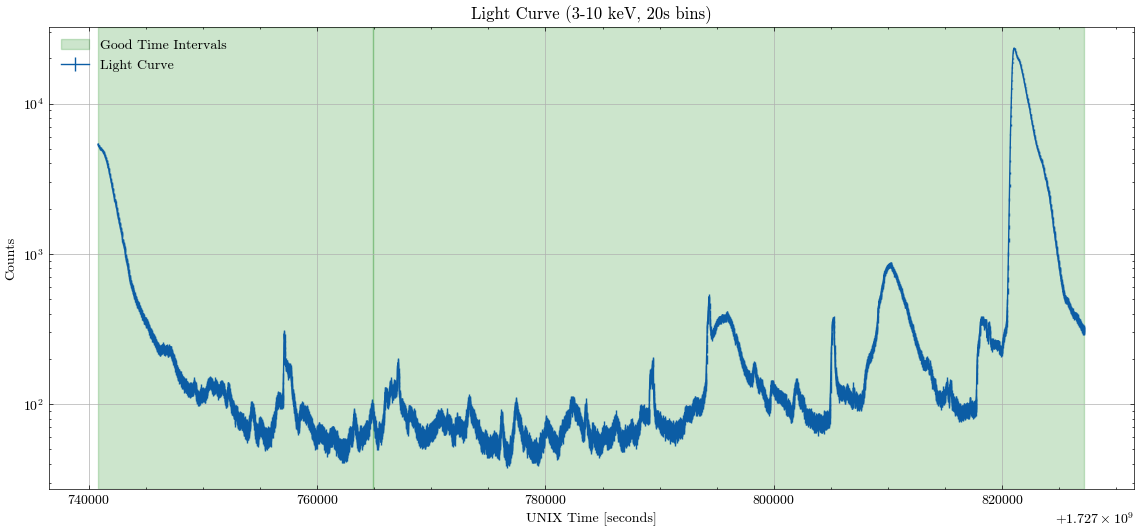

In [53]:
new_lc_filename = '/home/idies/workspace/Storage/Prakhar_Singh/persistent/Data_2/Output_data/Lightcurve_data/AL1_SOLEXS_20241001_SDD2_L1_2_22keV_tbin20s.lc'

# Loading light curve (LC) file
lc_hdul = fits.open(new_lc_filename)
plot_times_UNIX = lc_hdul[1].data['TIME'] # here, time is in UNIX seconds
plot_lcurve = lc_hdul[1].data['COUNTS']

# Loading good time intervals (GTI) file
if(gti_filename is not None):
    gti_hdul = fits.open(gti_filename)
    gti_start_arr_UNIX = gti_hdul[1].data['START'] # here, time is in UNIX seconds
    gti_stop_arr_UNIX = gti_hdul[1].data['STOP'] # here, time is in UNIX seconds

fig, ax = plt.subplots(figsize=(14, 6))

ax.errorbar(plot_times_UNIX,plot_lcurve,yerr=np.sqrt(plot_lcurve),label='Light Curve')

if(gti_filename is not None):
    for n,i,j in zip(np.arange(len(gti_start_arr_UNIX)), gti_start_arr_UNIX, gti_stop_arr_UNIX):
        ax.axvspan(i,j, color='green', alpha=0.2, label='_'*n + 'Good Time Intervals')

ax.legend(loc=0)
ax.grid()
ax.set_yscale('log')

ax.set_xlabel('UNIX Time [seconds]')
ax.set_ylabel('Counts')
ax.set_title('Light Curve (3-10 keV, 20s bins)')

    

## Plot Light Curve for Flare Time 

In [14]:
# To use to get time from unix to utc or vise versa 
#! solexs-time2utc 1726133600
#! solexs-utc2time 2024-09-12T09:52:00

### Plot Light Curve for Flare in UNIX time 

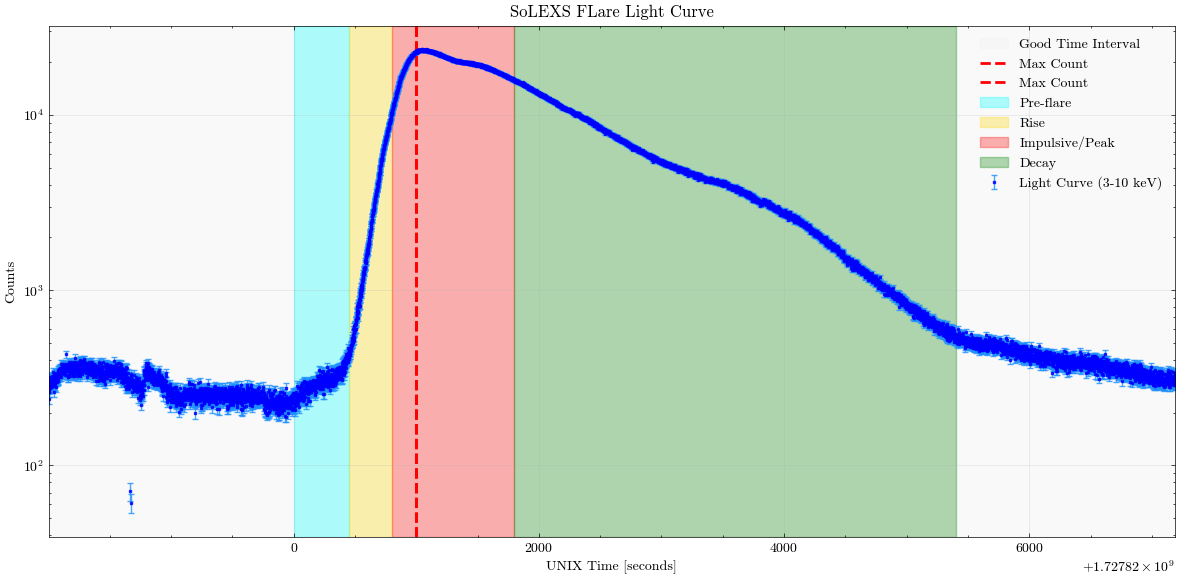

In [44]:
# Define time range for Light curve plotting
t_start = 1727818000
t_end = 1727827190


# Replace these with actual times from your flare
t_pre_start, t_pre_end = 1727820000, 1727820450
t_rise_start, t_rise_end = 1727820450, 1727820800
t_impulse_start, t_impulse_end = 1727820800, 1727821800
t_decay_start, t_decay_end = 1727821800, 1727825400                 # Decay

# Define integration period for the light curve
t_start_integration = t_pre_start
t_end_integration   = t_decay_end 
integration_period  = (t_start_integration, t_end_integration)

# Create figure
fig = plt.figure(figsize=(12, 6))

# Select data within the specified time range
idx = (plot_times_UNIX > t_start) & (plot_times_UNIX < t_end)

# Plot light curve with error bars
plt.errorbar(x=plot_times_UNIX[idx], y=plot_lcurve[idx],
             yerr=np.sqrt(plot_lcurve[idx]), fmt='s', markersize=2,capsize=2,
             c='b', label='Light Curve (3-10 keV)', alpha=0.8,ecolor='dodgerblue')

# Plot GTI if available
if gti_filename is not None:
    for n, start, stop in zip(np.arange(len(gti_start_arr_UNIX)), gti_start_arr_UNIX, gti_stop_arr_UNIX):
        plt.axvspan(start, stop, color='whitesmoke', alpha=0.5, label='_'*n + 'Good Time Interval')
        plt.axvline(1727821000, color='red', linestyle='--', lw=2, label='Max Count')
# Plot integration period
#plt.axvspan(*integration_period, alpha=0.5, color='khaki', label='Integration Period')

# ---- Highlight Flare Phases ----
phase_colors = {
    'Pre-flare': {'start': t_pre_start, 'end': t_pre_end, 'color': 'cyan'},
    'Rise': {'start': t_rise_start, 'end': t_rise_end, 'color': 'gold'},
    'Impulsive/Peak': {'start': t_impulse_start, 'end': t_impulse_end, 'color': 'red'},
    'Decay': {'start': t_decay_start, 'end': t_decay_end, 'color': 'green'}
}

for name, phase in phase_colors.items():
    plt.axvspan(phase['start'], phase['end'], color=phase['color'], alpha=0.3, label=name)

# Customize plot
plt.legend(loc='upper right')
plt.grid(True, alpha=0.3)
plt.yscale('log')
plt.xlim(plot_times_UNIX[idx][0], plot_times_UNIX[idx][-1])
plt.xlabel('UNIX Time [seconds]')
plt.ylabel('Counts')
plt.title('SoLEXS FLare Light Curve')

plt.tight_layout()
plt.show()

### Plotting Light Curve In UTC Time 

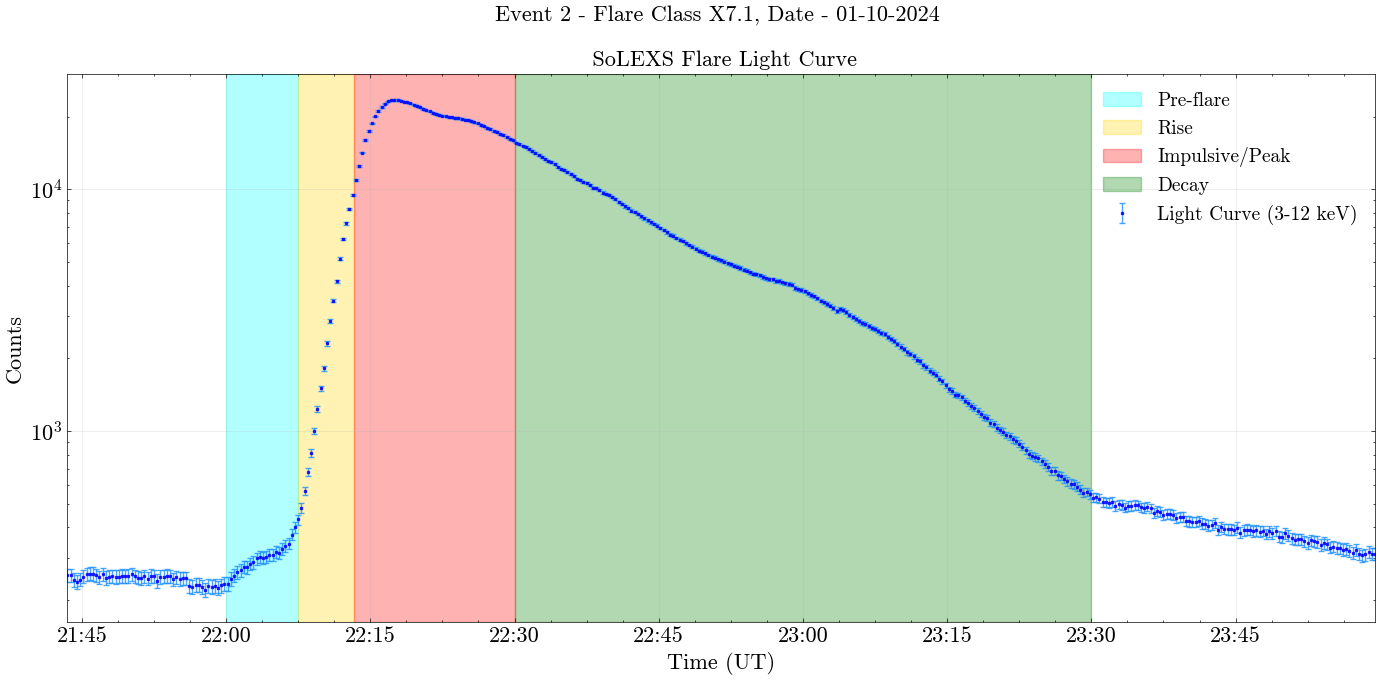

In [68]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime

# Define time range for Light curve plotting
t_start = 1727819000
t_end = 1727827190


# Convert all Unix timestamps to datetime
def unix_to_datetime(timestamp):
    return pd.to_datetime(timestamp, unit='s')

# Convert time ranges to datetime
t_pre_start, t_pre_end = 1727820000, 1727820450
t_rise_start, t_rise_end = 1727820450, 1727820800
t_impulse_start, t_impulse_end = 1727820800, 1727821800
t_decay_start, t_decay_end = 1727821800, 1727825400

# Convert all timestamps to datetime
plot_times_datetime = pd.to_datetime(plot_times_UNIX, unit='s')
t_start_dt = unix_to_datetime(t_start)
t_end_dt = unix_to_datetime(t_end)

# Phase times in datetime
phase_times = {
    'Pre-flare': {
        'start': unix_to_datetime(t_pre_start),
        'end': unix_to_datetime(t_pre_end),
        'color': 'cyan'
    },
    'Rise': {
        'start': unix_to_datetime(t_rise_start),
        'end': unix_to_datetime(t_rise_end),
        'color': 'gold'
    },
    'Impulsive/Peak': {
        'start': unix_to_datetime(t_impulse_start),
        'end': unix_to_datetime(t_impulse_end),
        'color': 'red'
    },
    'Decay': {
        'start': unix_to_datetime(t_decay_start),
        'end': unix_to_datetime(t_decay_end),
        'color': 'green'
    }
}

# Create figure
fig = plt.figure(figsize=(14, 7))

# Select data within the specified time range
idx = (plot_times_datetime > t_start_dt) & (plot_times_datetime < t_end_dt)

# Plot light curve with error bars
plt.errorbar(x=plot_times_datetime[idx], y=plot_lcurve[idx],yerr=np.sqrt(plot_lcurve[idx]), fmt='s', markersize=2, capsize=2,
             c='b', label='Light Curve (3-12 keV)', alpha=0.8,ecolor='dodgerblue')


# Plot flare phases
for name, phase in phase_times.items():
    plt.axvspan(phase['start'], phase['end'],color=phase['color'], alpha=0.3, label=name)

# Customize plot
plt.legend(loc='upper right',fontsize=14)
plt.grid(True, alpha=0.3)
plt.yscale('log')
plt.xlim(plot_times_datetime[idx][0], plot_times_datetime[idx][-1])
plt.xlabel('Time (UT)',fontsize=16)
plt.ylabel('Counts',fontsize=16)
plt.title('Event 2 - Flare Class X7.1, Date - 01-10-2024 \n \n SoLEXS Flare Light Curve',fontsize=16)
plt.tick_params(axis='both', labelsize=16)
# Rotate x-axis labels for better readability
#plt.gcf().autofmt_xdate()

# Use DateFormatter to format the x-axis
from matplotlib.dates import DateFormatter
plt.gca().xaxis.set_major_formatter(DateFormatter('%H:%M'))

plt.tight_layout()

plt.savefig("/home/idies/workspace/Storage/Prakhar_Singh/persistent/Data_2/Output_data/Fittingphases.png",dpi=300)
plt.show()

# Generating Spectrum file


In [43]:
# Check the help message for solexs-genspec  ( single Type I PI spectrum file )
# This will show you the available options and their descriptions
#!solexs-genspec -h


In [44]:
# Check the help message for solexs-genmultispec   ( muliple Type I PI spectrum file )
# This will show you the available options and their descriptions
#! solexs-genmultispec -h

## Selecting time-interval for integrated spectrum generation


In [10]:
spectral_output_path = "/home/idies/workspace/Storage/Prakhar_Singh/persistent/Data_2/Output_data/Spectral_data"
os.makedirs(spectral_output_path, exist_ok=True)

mode = 'single_folder'  # change to 'multi_folder' if needed if you want to store spectrum file according to each flare phase 
# mode = 'multi_folder'

# --- Define Flare Phases with Custom Time Bins ---
flare_phases = {
    'pre_flare': {
        'tstart': t_pre_start,
        'tstop': t_pre_end,
        'tbin': 50  
    },
    'rise': {
        'tstart': t_rise_start,
        'tstop': t_rise_end,
        'tbin': 10
    },
    'impulsive': {
        'tstart': t_impulse_start,
        'tstop': t_impulse_end,
        'tbin': 5
    },
    'decay': {
        'tstart': t_decay_start,
        'tstop': t_decay_end ,
        'tbin': 50
    }
}

# Loop through each phase and run solexs-genmultispec
for phase_name, params in flare_phases.items():
    print(f"\nProcessing {phase_name.upper()} phase...")
    tstart = params['tstart']
    tstop = params['tstop']
    tbin = params['tbin']

    if mode == 'single_folder':
        # Save all in one folder with prefix
        cmd = (
            f"solexs-genmultispec -i {pi_filename} "
            f"-tstart {tstart} -tstop {tstop} "
            f"-tbin {tbin} "
            f"-gti {gti_filename} "
            f"-o {spectral_output_path} -c True "
        )
    elif mode == 'multi_folder':
        # Create subdirectory for each phase
        phase_output_dir = os.path.join(spectral_output_path, phase_name)
        os.makedirs(phase_output_dir, exist_ok=True)
        cmd = (
            f"solexs-genmultispec -i {pi_filename} "
            f"-tstart {tstart} -tstop {tstop} "
            f"-tbin {tbin} "
            f"-gti {gti_filename} "
            f"-o {phase_output_dir} -c True"
        )
    else:
        raise ValueError("Invalid mode selected. Choose 'single_folder' or 'multi_folder'.")

    print(f"Running: {cmd}")
    os.system(cmd)  # Execute command


Processing PRE_FLARE phase...
Running: solexs-genmultispec -i /home/idies/workspace/sciserver_cookbooks/SoLEXS/Data/AL1_SLX_L1_20241001_v1.0/SDD2/AL1_SOLEXS_20241001_SDD2_L1.pi.gz -tstart 1727820000 -tstop 1727820450 -tbin 50 -gti /home/idies/workspace/sciserver_cookbooks/SoLEXS/Data/AL1_SLX_L1_20241001_v1.0/SDD2/AL1_SOLEXS_20241001_SDD2_L1.gti.gz -o /home/idies/workspace/Storage/Prakhar_Singh/persistent/Data_2/Output_data/Spectral_data -c True 
Start Time: 2024-10-01T22:00:00+00:00
Stop Time: 2024-10-01T22:07:30+00:00
Time Bin: 50.0 seconds
Output Directory: /home/idies/workspace/Storage/Prakhar_Singh/persistent/Data_2/Output_data/Spectral_data
ARF: /home/idies/workspace/sciserver_cookbooks/SoLEXS/Software/solexs_tools-1.1/CALDB/arf/solexs_arf_SDD2_v1.arf
RMF: /home/idies/workspace/sciserver_cookbooks/SoLEXS/Software/solexs_tools-1.1/CALDB/response/rmf/solexs_gaussian_SDD2_v1.rmf
Generated spectrum for time range 2024-10-01T22:00:00 to 2024-10-01T22:00:50: /home/idies/workspace/Stora

In [11]:
import os

# Define the directory path
spec_txt_directory = "/home/idies/workspace/Storage/Prakhar_Singh/persistent/Data_2/Output_data/Spectral_data/"

# Output text file to save the paths
txt_output_file = "/home/idies/workspace/Storage/Prakhar_Singh/persistent/Data_2/Output_data/Spectral_data/spectral_data_file_paths.txt"

# Collect only .pi file paths
pi_file_paths = []
for root, dirs, files in os.walk(spec_txt_directory):
    for file in files:
        if file.endswith(".pi"):
            full_path = os.path.join(root, file)
            pi_file_paths.append(full_path)

# Sort .pi file paths alphabetically
pi_file_paths.sort()

# Write sorted .pi file paths to the output file
with open(txt_output_file, "w") as f:
    for path in pi_file_paths:
        f.write(path + "\n")

print(f"Sorted .pi file paths saved to {txt_output_file}")


Sorted .pi file paths saved to /home/idies/workspace/Storage/Prakhar_Singh/persistent/Data_2/Output_data/Spectral_data/spectral_data_file_paths.txt
